## Preparación de datos desde GitHub

Ejecuta esta celda primero en Google Colab. Descarga las dos tablas ENOE completas y verifica sus hashes antes de guardarlas en tu Drive. Requiere que los ZIP y manifest.json ya estén publicados en la rama main. No reemplaza CSV existentes que sean diferentes.

Las siguientes seis celdas de código y sus resultados son los originales; esta celda de preparación se agregó para facilitar la reproducción. No se ha reentrenado el modelo.


In [ ]:
"""Obtiene los CSV completos del repositorio y verifica su integridad."""
from pathlib import Path
from tempfile import TemporaryDirectory
import hashlib
import json
import shutil
import urllib.request
import zipfile

BASE_GITHUB = 'https://raw.githubusercontent.com/LuisMario97/BlueWage/main/backend/datos/'
ARCHIVOS = {'ENOE_COE1T226.csv', 'ENOE_SDEMT226.csv'}


def sha256_archivo(ruta):
    with Path(ruta).open('rb') as archivo:
        return hashlib.file_digest(archivo, 'sha256').hexdigest()


def preparar_datos(destino, base_url=BASE_GITHUB):
    """Usa archivos existentes si coinciden; no sobrescribe CSV diferentes."""
    destino = Path(destino)
    destino.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(base_url + 'manifest.json', timeout=60) as respuesta:
        manifest = json.load(respuesta)
    if len(manifest) != 2 or {item['archivo'] for item in manifest} != ARCHIVOS:
        raise ValueError('El manifiesto no contiene las dos tablas esperadas.')
    for item in manifest:
        nombre = item['archivo']
        if item['zip'] != nombre + '.zip':
            raise ValueError('Nombre de ZIP inesperado.')
        salida = destino / nombre
        if salida.exists():
            if sha256_archivo(salida) != item['sha256_csv']:
                raise ValueError(f'{salida} ya existe y no coincide. Revisa ese archivo o elige otra carpeta.')
            print(f'{nombre}: ya disponible y verificado.')
            continue
        with TemporaryDirectory() as temporal:
            zip_local = Path(temporal) / item['zip']
            print(f'Descargando {nombre}…')
            with urllib.request.urlopen(base_url + item['zip'], timeout=120) as respuesta, zip_local.open('wb') as archivo:
                shutil.copyfileobj(respuesta, archivo)
            if sha256_archivo(zip_local) != item['sha256_zip']:
                raise ValueError(f'ZIP incompleto o alterado: {nombre}.')
            csv_local = Path(temporal) / nombre
            with zipfile.ZipFile(zip_local) as zip_datos:
                if zip_datos.namelist() != [nombre]:
                    raise ValueError('El ZIP contiene archivos inesperados.')
                with zip_datos.open(nombre) as entrada, csv_local.open('wb') as archivo:
                    shutil.copyfileobj(entrada, archivo)
            if sha256_archivo(csv_local) != item['sha256_csv']:
                raise ValueError(f'El CSV no coincide: {nombre}.')
            # Escritura exclusiva para no reemplazar datos preexistentes.
            with csv_local.open('rb') as entrada, salida.open('xb') as archivo:
                shutil.copyfileobj(entrada, archivo)
        print(f'{nombre}: listo ({item["filas"]:,} registros).')
    return destino



from google.colab import drive
drive.mount("/content/drive")
preparar_datos("/content/drive/MyDrive/BlueWage/Datos")


Montaje de Drive y Carga Optimizada de ENOE

In [2]:
from pathlib import Path

import pandas as pd
from google.colab import drive
from IPython.display import display

drive.mount("/content/drive")

CARPETA = Path("/content/drive/MyDrive/BlueWage/Datos")
PERIODO = "226"

# Llaves de persona para relacionar las tablas de este periodo.
LLAVES = [
    "tipo", "mes_cal", "cd_a", "ent", "con",
    "v_sel", "n_hog", "h_mud", "n_ren",
]


def localizar_tabla(tabla):
    """Busca el CSV con o sin prefijo ENOE_, ignorando mayúsculas."""
    nombres = {
        f"enoe_{tabla}{PERIODO}.csv".lower(),
        f"{tabla}{PERIODO}.csv".lower(),
    }
    candidatos = [
        archivo
        for archivo in CARPETA.iterdir()
        if archivo.is_file() and archivo.name.lower() in nombres
    ]

    if not candidatos:
        raise FileNotFoundError(
            f"Falta la tabla {tabla}{PERIODO}. "
            f"Agrega su CSV del mismo periodo a {CARPETA}. "
            f"Nombres aceptados: {sorted(nombres)}"
        )
    if len(candidatos) > 1:
        raise ValueError(
            f"Hay varios archivos para {tabla}: "
            f"{[archivo.name for archivo in candidatos]}. "
            "Conserva una sola versión para evitar ambigüedad."
        )
    return candidatos[0]


def leer_columnas(ruta, requeridas, opcionales=()):
    """Carga solo los campos necesarios y normaliza sus nombres."""
    alias = {"cve_ent": "ent"}

    for encoding in ("utf-8-sig", "latin-1"):
        try:
            encabezado = pd.read_csv(ruta, nrows=0, encoding=encoding)

            columnas = {}
            for original in encabezado.columns:
                nombre = original.strip().lower()
                canonico = alias.get(nombre, nombre)
                if canonico in columnas:
                    raise ValueError(
                        f"{ruta.name}: columnas ambiguas para '{canonico}'."
                    )
                columnas[canonico] = original

            faltantes = set(requeridas) - set(columnas)
            if faltantes:
                raise ValueError(
                    f"{ruta.name}: faltan columnas {sorted(faltantes)}."
                )

            seleccion = {
                columnas[nombre]: nombre
                for nombre in (*requeridas, *opcionales)
                if nombre in columnas
            }

            datos = pd.read_csv(
                ruta,
                usecols=list(seleccion),
                dtype="string",
                encoding=encoding,
                low_memory=False,
            ).rename(columns=seleccion)

            # Mantiene ceros iniciales y elimina espacios externos.
            for columna in datos.columns:
                datos[columna] = datos[columna].str.strip().replace("", pd.NA)

            return datos

        except UnicodeDecodeError:
            if encoding == "latin-1":
                raise


def validar_llaves(datos, nombre):
    """Impide cruces ambiguos o registros con identificación incompleta."""
    if datos[LLAVES].isna().any().any():
        raise ValueError(f"{nombre}: hay valores ausentes en las llaves.")
    if datos.duplicated(LLAVES).any():
        raise ValueError(f"{nombre}: hay llaves de persona duplicadas.")


ruta_sdem = localizar_tabla("SDEMT")
df_sdem = leer_columnas(
    ruta_sdem,
    requeridas=LLAVES + ["eda", "hrsocup", "ingocup"],
    opcionales=["scian"],
)
print(f"Filas cargadas originalmente de SDEMT: {len(df_sdem):,}")

ruta_coe = localizar_tabla("COE1T")
df_coe = leer_columnas(
    ruta_coe,
    requeridas=LLAVES + ["p3"],
).rename(columns={"p3": "sinco"})

validar_llaves(df_sdem, ruta_sdem.name)
validar_llaves(df_coe, ruta_coe.name)

# Conserva todas las personas de SDEMT y verifica una unión uno a uno.
df_enoe = df_sdem.merge(
    df_coe,
    on=LLAVES,
    how="left",
    validate="one_to_one",
    indicator=True,
)

coincidencias = df_enoe["_merge"].eq("both").sum()
print(f"Personas con coincidencia en COE1T: {coincidencias:,}")

if coincidencias == 0:
    raise ValueError(
        "No hubo coincidencias. Revisa que ambos archivos correspondan "
        "al mismo periodo y que sus llaves tengan el mismo formato."
    )

# Libera las columnas auxiliares y las tablas intermedias.
columnas_finales = ["ent", "eda", "sinco", "hrsocup", "ingocup"]
if "scian" in df_enoe.columns:
    columnas_finales.append("scian")

df_enoe = df_enoe[columnas_finales].copy()
del df_sdem, df_coe

print(f"Filas disponibles antes del filtrado: {len(df_enoe):,}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Filas cargadas originalmente de SDEMT: 417,128
Personas con coincidencia en COE1T: 344,709
Filas disponibles antes del filtrado: 417,128


Filtrado, limpieza y mapeo

In [4]:
# Mapeo solicitado para BlueWage.
PUESTOS = {
    8341: "Conductores de carga",
    8352: "Operadores de maquinaria para mover mercancías",
    3132: "Personal de control de almacén",
    9331: "Personal de carga y descarga",
}

INGRESOS_NO_RESPUESTA = {99999, 999999}


def filtrar_logistica(datos):
    """Selecciona ocupaciones y aplica los criterios de calidad laboral."""
    # Normaliza los campos usados en los filtros.
    # Valores vacíos o no numéricos se convierten en ausentes.
    numericas = {
        columna: pd.to_numeric(
            datos[columna].str.strip(),
            errors="coerce",
        )
        for columna in ("sinco", "eda", "hrsocup", "ingocup")
    }

    # La selección sectorial solicitada se basa en ocupación SINCO.
    mascara = (
        numericas["sinco"].isin(PUESTOS)
        & numericas["eda"].between(18, 65, inclusive="both")
        & numericas["hrsocup"].between(20, 72, inclusive="both")
        & numericas["ingocup"].gt(0)
        & ~numericas["ingocup"].isin(INGRESOS_NO_RESPUESTA)
    ).fillna(False)

    # Copia únicamente las filas seleccionadas para limitar el uso de RAM.
    resultado = datos.loc[mascara].copy()
    for columna, valores in numericas.items():
        resultado[columna] = valores.loc[mascara]

    resultado["sinco"] = resultado["sinco"].astype("Int64")
    resultado["puesto"] = resultado["sinco"].map(PUESTOS)

    return resultado.reset_index(drop=True)


df_logistica = filtrar_logistica(df_enoe)

print(f"Registros antes del filtrado:   {len(df_enoe):,}")
print(f"Registros después del filtrado: {len(df_logistica):,}")
print(f"Registros eliminados:          {len(df_enoe) - len(df_logistica):,}")

if df_logistica.empty:
    print("No hay registros que cumplan todos los criterios.")
else:
    resumen = (
        df_logistica
        .groupby("puesto")[["ingocup", "hrsocup"]]
        .describe()
        .round(2)
    )
    display(resumen)

Registros antes del filtrado:   417,128
Registros después del filtrado: 4,547
Registros eliminados:          412,581


ingocup                     \
                                                 count      mean      std   
puesto                                                                      
Conductores de carga                            2137.0  14287.69  9222.82   
Operadores de maquinaria para mover mercancías   572.0  13205.45  7253.26   
Personal de carga y descarga                     619.0   9959.01  4504.01   
Personal de control de almacén                  1219.0  12130.73  5379.44   

                                                                          \
                                                   min      25%      50%   
puesto                                                                     
Conductores de carga                             516.0   9890.0  12900.0   
Operadores de maquinaria para mover mercancías  3010.0  10750.0  12470.0   
Personal de carga y descarga                    1490.0   7740.0   9460.0   
Personal de control de almacén                   860.0   9030.0  10750.0   

                                                                  hrsocup  \
                                                    75%       max   count   
puesto                                                                      
Conductores de carga                            16000.0  193500.0  2137.0   
Operadores de maquinaria para mover mercancías  15050.0  150000.0   572.0   
Personal de carga y descarga                    10982.5   64706.0   619.0   
Personal de control de almacén                  13522.5   73100.0  1219.0   

                                                                          \
                                                 mean    std   min   25%   
puesto                                                                     
Conductores de carga                            50.16  11.11  20.0  45.0   
Operadores de maquinaria para mover mercancías  47.83   7.27  24.0  45.0   
Personal de carga y descarga                    48.22  11.48  20.0  44.5   
Personal de control de almacén                   46.5   7.05  20.0  45.0   

                                                                  
                                                 50%   75%   max  
puesto                                                            
Conductores de carga                            48.0  57.0  72.0  
Operadores de maquinaria para mover mercancías  48.0  48.0  72.0  
Personal de carga y descarga                    48.0  55.0  72.0  
Personal de control de almacén                  48.0  48.0  72.0

Tratamiento de extremos, EDA y parámetros salariales


Método de recorte: percentiles
Intervalo conservado: $3,870.00–$43,000.00 MXN
Registros antes:     4,547
Registros después:   4,469
Registros retirados: 78
Porcentaje conservado: 98.28%


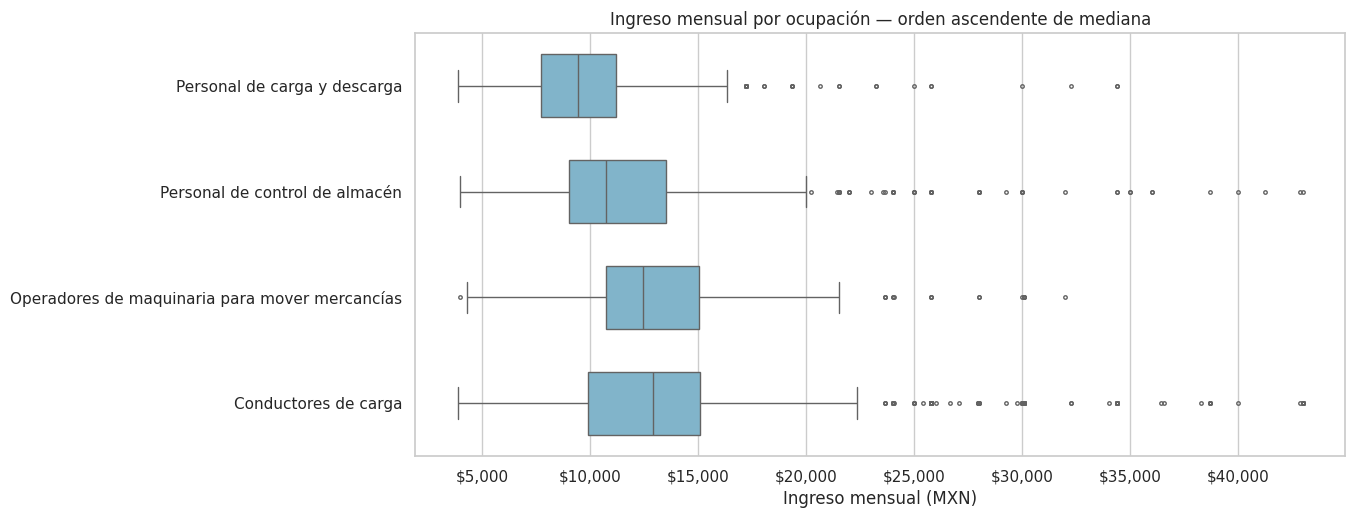

Figura guardada: /content/figuras_eda/fig1_salario_por_puesto.png


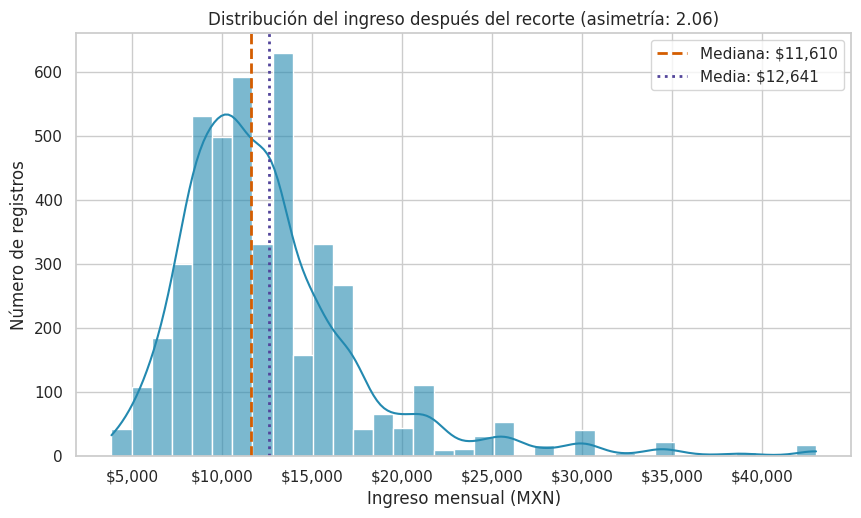

Figura guardada: /content/figuras_eda/fig2_distribucion_sesgo.png
Asimetría muestral después del recorte: 2.063
La mediana resume el centro con menor sensibilidad a extremos. La regresión cuantílica permite estimar distintos puntos de la distribución salarial condicionados a las características del trabajador.


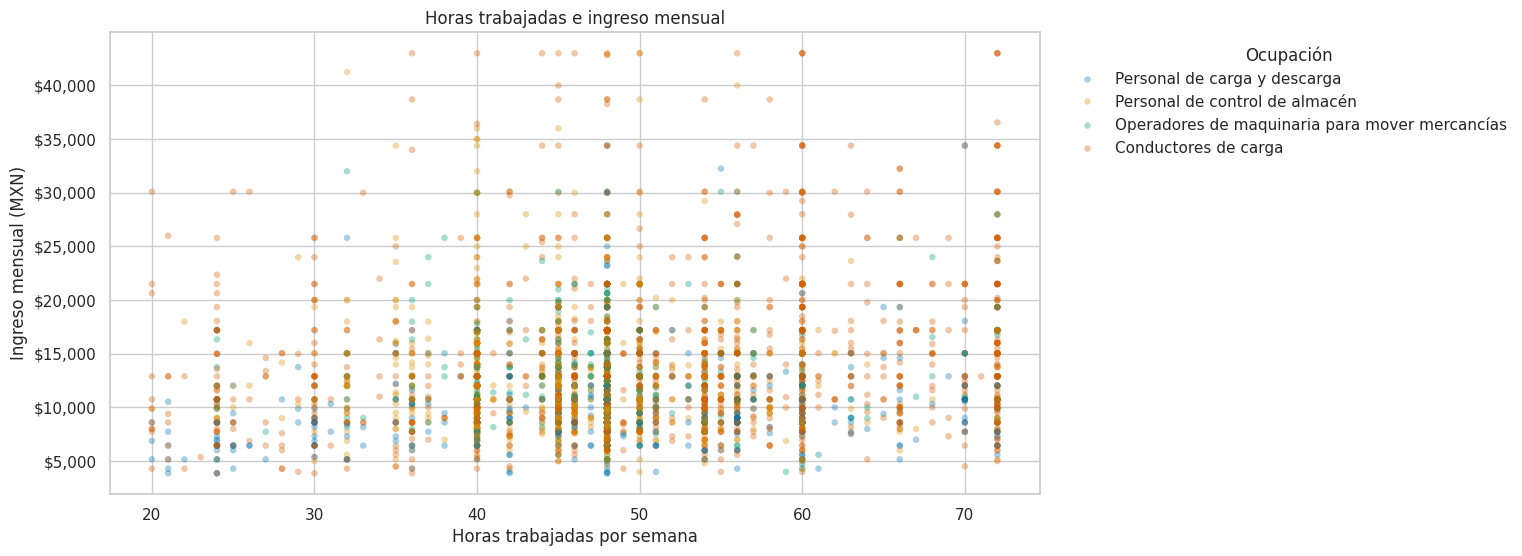

Figura guardada: /content/figuras_eda/fig3_horas_vs_salario.png

Parámetros ENOE por puesto — MXN mensuales:
{
    "Personal de carga y descarga": {
        "p10": 6450,
        "p50": 9460,
        "p90": 14620
    },
    "Personal de control de almacén": {
        "p10": 7869,
        "p50": 10750,
        "p90": 17200
    },
    "Operadores de maquinaria para mover mercancías": {
        "p10": 8600,
        "p50": 12470,
        "p90": 17840
    },
    "Conductores de carga": {
        "p10": 7740,
        "p50": 12900,
        "p90": 21500
    }
}


In [5]:


import os
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# -------------------------------------------------------------------
# 1. Configuración y recorte de ingresos
# -------------------------------------------------------------------
METODO_RECORTE = "percentiles"  # Alternativa: "limites_fijos"
PISO_MXN = 6_500
TECHO_MXN = 45_000

CARPETA_FIGURAS = "figuras_eda"
os.makedirs("figuras_eda", exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")


def recortar_ingresos(datos, metodo="percentiles"):
    """Aplica un recorte global inclusivo; no modifica el DataFrame original."""
    requeridas = {"puesto", "ingocup", "hrsocup"}
    faltantes = requeridas - set(datos.columns)
    if faltantes:
        raise ValueError(f"Faltan columnas: {sorted(faltantes)}")
    if datos.empty:
        raise ValueError("df_logistica no contiene registros.")

    ingresos = pd.to_numeric(datos["ingocup"], errors="coerce")

    if metodo == "percentiles":
        inferior, superior = ingresos.quantile([0.01, 0.99])
    elif metodo == "limites_fijos":
        inferior, superior = PISO_MXN, TECHO_MXN
    else:
        raise ValueError("Usa 'percentiles' o 'limites_fijos'.")

    if pd.isna(inferior) or pd.isna(superior):
        raise ValueError("No hay ingresos válidos para calcular el recorte.")

    mascara = ingresos.between(inferior, superior).fillna(False)
    filtrado = datos.loc[mascara].copy()
    filtrado["ingocup"] = ingresos.loc[mascara].astype(float)

    if filtrado.empty:
        raise ValueError("El recorte eliminó todos los registros.")

    return filtrado, float(inferior), float(superior)


df_filtrado, limite_inferior, limite_superior = recortar_ingresos(
    df_logistica,
    metodo=METODO_RECORTE,
)

print(f"Método de recorte: {METODO_RECORTE}")
print(f"Intervalo conservado: ${limite_inferior:,.2f}–${limite_superior:,.2f} MXN")
print(f"Registros antes:     {len(df_logistica):,}")
print(f"Registros después:   {len(df_filtrado):,}")
print(f"Registros retirados: {len(df_logistica) - len(df_filtrado):,}")
print(f"Porcentaje conservado: {len(df_filtrado) / len(df_logistica):.2%}")

puestos_perdidos = (
    set(df_logistica["puesto"].dropna())
    - set(df_filtrado["puesto"].dropna())
)
if puestos_perdidos:
    print(f"Puestos sin registros tras el recorte: {sorted(puestos_perdidos)}")

# Orden común para gráficas y parámetros.
orden_puestos = (
    df_filtrado.groupby("puesto")["ingocup"]
    .median()
    .sort_values()
    .index.tolist()
)

formato_mxn = FuncFormatter(lambda valor, _: f"${valor:,.0f}")


def guardar_y_mostrar(figura, nombre):
    """Exporta la figura para LaTeX y la muestra en Colab."""
    ruta = os.path.join(CARPETA_FIGURAS, nombre)
    figura.savefig(ruta, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(figura)
    print(f"Figura guardada: {os.path.abspath(ruta)}")


# -------------------------------------------------------------------
# 2. Figura 1: distribución salarial por puesto
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5.5))

sns.boxplot(
    data=df_filtrado,
    x="ingocup",
    y="puesto",
    order=orden_puestos,
    color="#75B9D6",
    width=0.6,
    fliersize=2.5,
    ax=ax,
)

ax.set(
    title="Ingreso mensual por ocupación — orden ascendente de mediana",
    xlabel="Ingreso mensual (MXN)",
    ylabel="",
)
ax.xaxis.set_major_formatter(formato_mxn)

guardar_y_mostrar(fig, "fig1_salario_por_puesto.png")


# -------------------------------------------------------------------
# 3. Figura 2: histograma, KDE, media y mediana
# -------------------------------------------------------------------
salarios = df_filtrado["ingocup"]
media = salarios.mean()
mediana = salarios.median()
asimetria = salarios.skew()

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.histplot(
    data=df_filtrado,
    x="ingocup",
    bins=35,
    kde=salarios.nunique() > 1,
    color="#2389B0",
    alpha=0.6,
    ax=ax,
)

ax.axvline(
    mediana, color="#D45D00", linestyle="--", linewidth=2,
    label=f"Mediana: ${mediana:,.0f}",
)
ax.axvline(
    media, color="#53459B", linestyle=":", linewidth=2,
    label=f"Media: ${media:,.0f}",
)

ax.set(
    title=f"Distribución del ingreso después del recorte (asimetría: {asimetria:.2f})",
    xlabel="Ingreso mensual (MXN)",
    ylabel="Número de registros",
)
ax.xaxis.set_major_formatter(formato_mxn)
ax.legend()

guardar_y_mostrar(fig, "fig2_distribucion_sesgo.png")

# Se reporta el sesgo observado; no se presupone su dirección.
print(f"Asimetría muestral después del recorte: {asimetria:.3f}")
print(
    "La mediana resume el centro con menor sensibilidad a extremos. "
    "La regresión cuantílica permite estimar distintos puntos de la "
    "distribución salarial condicionados a las características del trabajador."
)


# -------------------------------------------------------------------
# 4. Figura 3: horas semanales frente a ingreso mensual
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df_filtrado,
    x="hrsocup",
    y="ingocup",
    hue="puesto",
    hue_order=orden_puestos,
    palette="colorblind",
    alpha=0.35,
    s=22,
    linewidth=0,
    ax=ax,
)

ax.set(
    title="Horas trabajadas e ingreso mensual",
    xlabel="Horas trabajadas por semana",
    ylabel="Ingreso mensual (MXN)",
)
ax.yaxis.set_major_formatter(formato_mxn)
ax.legend(
    title="Ocupación",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False,
)

guardar_y_mostrar(fig, "fig3_horas_vs_salario.png")


# -------------------------------------------------------------------
# 5. Parámetros empíricos por puesto
# -------------------------------------------------------------------
# Percentiles de la muestra recortada, sin factores de expansión.
# Son bandas descriptivas; todavía no son predicciones de una regresión.
tabla_parametros = (
    df_filtrado.groupby("puesto")["ingocup"]
    .agg(
        p10=lambda x: round(x.quantile(0.10)),
        p50=lambda x: round(x.median()),
        p90=lambda x: round(x.quantile(0.90)),
    )
    .reindex(orden_puestos)
)

parametros_enoe = tabla_parametros.to_dict(orient="index")

print("\nParámetros ENOE por puesto — MXN mensuales:")
print(json.dumps(parametros_enoe, ensure_ascii=False, indent=4))

Aumentación sintética anclada en las medianas ENOE

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import truncnorm
from IPython.display import display

np.random.seed(42)

N_REGISTROS = 8_000
ARCHIVO_SALIDA = "bluewage_dataset_calibrado.csv"

PESOS_PUESTO = {
    "Conductores de carga": 0.40,
    "Personal de control de almacén": 0.25,
    "Operadores de maquinaria para mover mercancías": 0.20,
    "Personal de carga y descarga": 0.15,
}

REGIONES = [
    "CDMX/Edomex",
    "Nuevo León",
    "Jalisco",
    "Bajío",
    "Frontera Norte",
    "Resto del país",
]

LICENCIAS_POR_PUESTO = {
    "Conductores de carga": {
        "Federal B": 0.40,
        "Federal C": 0.25,
        "Federal E": 0.20,
        "Estatal Chofer": 0.15,
    },
    "Operadores de maquinaria para mover mercancías": {
        "Estatal Chofer": 0.40,
        "Federal B": 0.20,
        "Sin licencia": 0.40,
    },
    "Personal de control de almacén": {
        "Sin licencia": 0.75,
        "Estatal Chofer": 0.25,
    },
    "Personal de carga y descarga": {
        "Sin licencia": 0.75,
        "Estatal Chofer": 0.25,
    },
}

PROBABILIDAD_DC3 = {
    "Conductores de carga": 0.45,
    "Operadores de maquinaria para mover mercancías": 0.70,
    "Personal de control de almacén": 0.20,
    "Personal de carga y descarga": 0.20,
}

PRIMAS_LICENCIA = {
    "Sin licencia": 1.00,
    "Estatal Chofer": 1.00,
    "Federal B": 1.10,
    "Federal C": 1.18,
    "Federal E": 1.30,
}


def generar_experiencia(n):
    """Gamma sesgada hacia experiencia baja/moderada, truncada a 30 años."""
    valores = np.random.gamma(shape=2.5, scale=3.0, size=n)

    # Muestreo por rechazo: evita acumular valores artificialmente en 30.
    fuera = valores > 30
    while fuera.any():
        valores[fuera] = np.random.gamma(
            shape=2.5, scale=3.0, size=int(fuera.sum())
        )
        fuera = valores > 30

    return valores.round(1)


def generar_dataset(parametros, n):
    """Genera observaciones sintéticas; no concatena ni replica filas ENOE."""
    faltantes = set(PESOS_PUESTO) - set(parametros)
    if faltantes:
        raise ValueError(f"Faltan parámetros ENOE para: {sorted(faltantes)}")

    medianas = {
        puesto: float(parametros[puesto]["p50"])
        for puesto in PESOS_PUESTO
    }
    if any(not np.isfinite(valor) or valor <= 0 for valor in medianas.values()):
        raise ValueError("Las medianas ENOE deben ser finitas y positivas.")

    datos = pd.DataFrame({
        # Las proporciones observadas fluctuarán alrededor de los pesos.
        "puesto": np.random.choice(
            list(PESOS_PUESTO),
            size=n,
            p=list(PESOS_PUESTO.values()),
        ),
        "region": np.random.choice(REGIONES, size=n),
        "experiencia_anios": generar_experiencia(n),
        "horas_semana": truncnorm.rvs(
            a=(20 - 48) / 8,
            b=(72 - 48) / 8,
            loc=48,
            scale=8,
            size=n,
        ).round(1),
    })

    # Licencias condicionadas por ocupación.
    datos["licencia"] = pd.Series(index=datos.index, dtype="string")
    for puesto, probabilidades in LICENCIAS_POR_PUESTO.items():
        mascara = datos["puesto"].eq(puesto)
        datos.loc[mascara, "licencia"] = np.random.choice(
            list(probabilidades),
            size=int(mascara.sum()),
            p=list(probabilidades.values()),
        )

    # Certificación condicionada por ocupación.
    probabilidades_dc3 = datos["puesto"].map(PROBABILIDAD_DC3).to_numpy()
    datos["tiene_dc3"] = np.random.binomial(
        n=1, p=probabilidades_dc3
    ).astype("int8")

    # Base empírica y primas multiplicativas solicitadas.
    salario_base = datos["puesto"].map(medianas).to_numpy()

    factor_region = np.where(
        datos["region"].isin(["Nuevo León", "Frontera Norte"]),
        1.15,
        1.00,
    )
    factor_experiencia = 1 + 0.012 * datos["experiencia_anios"].to_numpy()
    factor_licencia = datos["licencia"].map(PRIMAS_LICENCIA).to_numpy(
        dtype=float
    )
    factor_dc3 = 1 + 0.12 * datos["tiene_dc3"].to_numpy()

    # Mediana del multiplicador = 1; sigma está en escala logarítmica.
    ruido = np.random.lognormal(mean=0.0, sigma=0.12, size=n)

    # Horas no modifica el target: no se especificó una prima por jornada.
    datos["salario_mensual"] = (
        salario_base
        * factor_region
        * factor_experiencia
        * factor_licencia
        * factor_dc3
        * ruido
    ).round(2)

    return datos


# Usa el diccionario parametros_enoe obtenido en la celda 3.
df_aumentado = generar_dataset(parametros_enoe, N_REGISTROS)

# Comprobaciones antes de exportar.
assert len(df_aumentado) == N_REGISTROS
assert not df_aumentado.isna().any().any()
assert df_aumentado["experiencia_anios"].between(0, 30).all()
assert df_aumentado["horas_semana"].between(20, 72).all()
assert df_aumentado["tiene_dc3"].isin([0, 1]).all()
assert np.isfinite(df_aumentado["salario_mensual"]).all()
assert df_aumentado["salario_mensual"].gt(0).all()

print(f"Registros sintéticos generados: {len(df_aumentado):,}")
display(df_aumentado.head())

resumen_sintetico = (
    df_aumentado.groupby("puesto")["salario_mensual"]
    .agg(["count", "min", "median", "mean", "max"])
    .reindex(list(PESOS_PUESTO))
    .round(2)
)
display(resumen_sintetico)

df_aumentado.to_csv(
    ARCHIVO_SALIDA,
    index=False,
    encoding="utf-8-sig",
)
print(f"CSV guardado: {ARCHIVO_SALIDA}")

Registros sintéticos generados: 8,000


,puesto,region,experiencia_anios,horas_semana,licencia,tiene_dc3,salario_mensual
0,Conductores de carga,Resto del país,9.0,37.8,Federal E,0,20137.01
1,Personal de carga y descarga,Nuevo León,3.8,40.9,Sin licencia,1,11710.67
2,Operadores de maquinaria para mover mercancías,Nuevo León,11.3,54.7,Estatal Chofer,0,14590.57
3,Personal de control de almacén,Jalisco,1.7,40.8,Estatal Chofer,0,9975.49
4,Conductores de carga,Frontera Norte,2.7,50.5,Federal B,0,16305.40


,count,min,median,mean,max
puesto,,,,,
Conductores de carga,3250,9553.02,17598.10,17923.22,32345.93
Personal de control de almacén,2019,7393.08,12570.89,12780.66,20418.96
Operadores de maquinaria para mover mercancías,1554,9247.75,15666.81,15867.67,27515.47
Personal de carga y descarga,1177,6948.04,10905.08,11048.50,17733.94


CSV guardado: bluewage_dataset_calibrado.csv


Preprocesamiento y regresión cuantílica con LightGBM


In [7]:
%pip install -q "lightgbm>=4.0,<5" "scikit-learn>=1.2,<2"

import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, d2_pinball_score
from IPython.display import display

# -------------------------------------------------------------------
# 1. Configuración y carga
# -------------------------------------------------------------------
SEMILLA = 42
ARCHIVO = "bluewage_dataset_calibrado.csv"
TARGET = "salario_mensual"

CATEGORICAS = ["puesto", "region", "licencia"]
NUMERICAS = ["experiencia_anios", "horas_semana", "tiene_dc3"]
CARACTERISTICAS = CATEGORICAS + NUMERICAS

CUANTILES = {"p10": 0.10, "p50": 0.50, "p90": 0.90}

df_modelado = pd.read_csv(ARCHIVO, encoding="utf-8-sig")

faltantes = set(CARACTERISTICAS + [TARGET]) - set(df_modelado.columns)
if faltantes:
    raise ValueError(f"Faltan columnas requeridas: {sorted(faltantes)}")

# Validaciones de integridad; no estiman parámetros del conjunto completo.
if df_modelado[CARACTERISTICAS + [TARGET]].isna().any().any():
    raise ValueError("Hay valores ausentes en las características o el target.")

for columna in NUMERICAS + [TARGET]:
    df_modelado[columna] = pd.to_numeric(
        df_modelado[columna], errors="raise"
    )

if not np.isfinite(df_modelado[NUMERICAS + [TARGET]].to_numpy()).all():
    raise ValueError("Se encontraron valores numéricos infinitos o no válidos.")

if not df_modelado[TARGET].gt(0).all():
    raise ValueError("El salario mensual debe ser positivo.")

# Selección explícita: evita incorporar accidentalmente columnas derivadas de y.
X = df_modelado[CARACTERISTICAS].copy()
y = df_modelado[TARGET].copy()

# -------------------------------------------------------------------
# 2. Partición antes de ajustar cualquier transformación
# -------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEMILLA,
)

print(f"Train: {len(X_train):,} registros")
print(f"Test:  {len(X_test):,} registros")

# -------------------------------------------------------------------
# 3. Preprocesamiento: aprendizaje exclusivamente sobre train
# -------------------------------------------------------------------
preprocesador = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            CATEGORICAS,
        ),
        ("numericas", "passthrough", NUMERICAS),
    ],
    remainder="drop",
)

X_train_procesado = preprocesador.fit_transform(X_train)
X_test_procesado = preprocesador.transform(X_test)

print(f"Características tras la transformación: {X_train_procesado.shape[1]}")

# -------------------------------------------------------------------
# 4. Entrenamiento de tres modelos independientes
# -------------------------------------------------------------------
def entrenar_cuantiles(X_entrenamiento, y_entrenamiento):
    """Entrena cada cuantil sin usar test para ajuste o selección."""
    modelos = {}

    for nombre, alpha in CUANTILES.items():
        modelo = lgb.LGBMRegressor(
            objective="quantile",
            alpha=alpha,
            n_estimators=150,
            learning_rate=0.05,
            random_state=SEMILLA,
            verbose=-1,
        )
        modelo.fit(X_entrenamiento, y_entrenamiento)
        modelos[nombre] = modelo

    return modelos


modelos_cuantilicos = entrenar_cuantiles(
    X_train_procesado,
    y_train,
)

# -------------------------------------------------------------------
# 5. Predicciones y evaluación en test
# -------------------------------------------------------------------
predicciones_test = pd.DataFrame(
    {
        nombre: modelo.predict(X_test_procesado)
        for nombre, modelo in modelos_cuantilicos.items()
    },
    index=y_test.index,
)

mae_mediana = mean_absolute_error(y_test, predicciones_test["p50"])
print(f"\nMAE de la mediana (P50): ${mae_mediana:,.2f} MXN")

# D² pinball evalúa cada modelo con su cuantil correspondiente.
metricas_cuantiles = pd.DataFrame([
    {
        "Modelo": nombre.upper(),
        "Cuantil": alpha,
        "D2 pinball": d2_pinball_score(
            y_test,
            predicciones_test[nombre],
            alpha=alpha,
        ),
    }
    for nombre, alpha in CUANTILES.items()
])

print("\nDesempeño por cuantil:")
display(metricas_cuantiles.round(4))

dentro_banda = (
    y_test.ge(predicciones_test["p10"])
    & y_test.le(predicciones_test["p90"])
)

# Los modelos independientes pueden producir cruces de cuantiles.
# Se reportan las predicciones originales sin reordenarlas.
cruces = (
    predicciones_test["p10"].gt(predicciones_test["p50"])
    | predicciones_test["p50"].gt(predicciones_test["p90"])
)

print(f"Cobertura observada P10–P90: {dentro_banda.mean():.2%}")
print("Cobertura nominal de referencia: 80% (no garantizada).")
print(f"Observaciones con cruces de cuantiles: {cruces.sum():,}")

comparacion_test = pd.DataFrame({
    "Salario Real": y_test,
    "Pred P10": predicciones_test["p10"],
    "Pred P50 (Mediana)": predicciones_test["p50"],
    "Pred P90": predicciones_test["p90"],
    "Dentro de banda": dentro_banda,
})

print("\nPrimeras cinco observaciones de test:")
display(comparacion_test.head().round(2))

# -------------------------------------------------------------------
# 6. Artefactos para inferencia posterior
# -------------------------------------------------------------------
# Conservados en memoria durante la sesión de Colab.
# En inferencia: usar transform(), nunca volver a ejecutar fit().
artefactos_bluewage = {
    "preprocesador": preprocesador,
    "modelos": modelos_cuantilicos,
    "caracteristicas": CARACTERISTICAS.copy(),
    "categoricas": CATEGORICAS.copy(),
    "numericas": NUMERICAS.copy(),
    "cuantiles": CUANTILES.copy(),
    "target": TARGET,
    "random_state": SEMILLA,
}

print("\nPreprocesador y modelos disponibles en 'artefactos_bluewage'.")

Train: 6,400 registros
Test:  1,600 registros
Características tras la transformación: 18

MAE de la mediana (P50): $1,481.57 MXN

Desempeño por cuantil:


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Modelo,Cuantil,D2 pinball
0,P10,0.1,0.4393
1,P50,0.5,0.5034
2,P90,0.9,0.4967


Cobertura observada P10–P90: 74.75%
Cobertura nominal de referencia: 80% (no garantizada).
Observaciones con cruces de cuantiles: 1

Primeras cinco observaciones de test:


,Salario Real,Pred P10,Pred P50 (Mediana),Pred P90,Dentro de banda
2215,15694.56,15335.73,17214.23,20062.98,True
2582,13369.70,10749.79,12224.18,14816.06,True
1662,10648.98,9375.71,11319.87,12713.87,True
3027,14763.64,11160.14,13601.07,15539.92,True
4343,18840.02,14491.58,17597.41,19579.36,True



Preprocesador y modelos disponibles en 'artefactos_bluewage'.


 Serialización, corrección de cruces e inferencia

In [8]:


import os
import json
import shutil
import joblib
import numpy as np
import pandas as pd

from google.colab import drive

RUTA_LOCAL = "bluewage_pipeline_cuantil.joblib"
CARPETA_DRIVE = "/content/drive/MyDrive/BlueWage/Datos"
RUTA_DRIVE = os.path.join(CARPETA_DRIVE, RUTA_LOCAL)

# -------------------------------------------------------------------
# 1. Empaquetado de los artefactos entrenados en la celda 5
# -------------------------------------------------------------------
pipeline_export = {
    "preprocessor": artefactos_bluewage["preprocesador"],
    "model_p10": artefactos_bluewage["modelos"]["p10"],
    "model_p50": artefactos_bluewage["modelos"]["p50"],
    "model_p90": artefactos_bluewage["modelos"]["p90"],

    # Columnas originales de entrada, antes del OneHotEncoder.
    "feature_names": list(artefactos_bluewage["caracteristicas"]),

    "meta": {
        "proyecto": "BlueWage",
        "version": "1.0.0",
        "mae_p50_test": 1481.57,
        "cobertura_test": 0.7475,
        "origen_test": "sintetico",
        "etapa_metricas": "antes_de_corregir_cruces",
        "correccion_cuantiles": "maximum_accumulate",
        "moneda": "MXN",
        "periodicidad": "mensual",
    },
}

joblib.dump(pipeline_export, RUTA_LOCAL, compress=3)
print(f"Modelo local: {os.path.abspath(RUTA_LOCAL)}")

# Monta Drive si todavía no está disponible.
if not os.path.isdir("/content/drive/MyDrive"):
    drive.mount("/content/drive")

os.makedirs(CARPETA_DRIVE, exist_ok=True)
shutil.copy2(RUTA_LOCAL, RUTA_DRIVE)
print(f"Respaldo en Drive: {RUTA_DRIVE}")


# -------------------------------------------------------------------
# 2. Validación del perfil de entrada
# -------------------------------------------------------------------
def preparar_perfil(datos_perfil_dict, columnas):
    """Convierte un perfil individual al esquema esperado por el modelo."""
    if not isinstance(datos_perfil_dict, dict):
        raise TypeError("El perfil debe ser un diccionario.")

    faltantes = set(columnas) - set(datos_perfil_dict)
    if faltantes:
        raise ValueError(f"Faltan campos del perfil: {sorted(faltantes)}")

    # Respeta el orden del entrenamiento y selecciona las columnas esperadas.
    perfil = pd.DataFrame([datos_perfil_dict]).loc[:, columnas]

    if perfil.isna().any().any():
        raise ValueError("El perfil contiene valores ausentes.")

    for columna in ["puesto", "region", "licencia"]:
        valor = perfil.at[0, columna]
        if not isinstance(valor, str) or not valor.strip():
            raise ValueError(f"'{columna}' debe ser un texto no vacío.")

    for columna in ["experiencia_anios", "horas_semana", "tiene_dc3"]:
        perfil[columna] = pd.to_numeric(perfil[columna], errors="raise")
        if not np.isfinite(perfil[columna].to_numpy(dtype=float)).all():
            raise ValueError(f"'{columna}' debe contener un número finito.")

    if not perfil["experiencia_anios"].between(0, 30).all():
        raise ValueError("La experiencia debe estar entre 0 y 30 años.")

    if not perfil["horas_semana"].between(20, 72).all():
        raise ValueError("Las horas semanales deben estar entre 20 y 72.")

    if not perfil["tiene_dc3"].isin([0, 1]).all():
        raise ValueError("'tiene_dc3' debe ser 0 o 1.")

    return perfil


# -------------------------------------------------------------------
# 3. Inferencia y corrección monotónica
# -------------------------------------------------------------------
def predecir_banda_salarial(datos_perfil_dict, ruta_modelo):
    """Devuelve una banda salarial mensual ordenada y serializable a JSON."""
    # Cargar únicamente archivos joblib propios o de origen confiable.
    pipeline = joblib.load(ruta_modelo)

    preprocessor = pipeline["preprocessor"]
    columnas = pipeline.get("feature_names")
    if columnas is None:
        columnas = list(preprocessor.feature_names_in_)

    perfil = preparar_perfil(datos_perfil_dict, columnas)

    # En inferencia solo se transforma: nunca se reajusta el preprocesador.
    perfil_transformado = preprocessor.transform(perfil)

    predicciones_crudas = np.array([
        pipeline["model_p10"].predict(perfil_transformado)[0],
        pipeline["model_p50"].predict(perfil_transformado)[0],
        pipeline["model_p90"].predict(perfil_transformado)[0],
    ], dtype=float)

    if not np.isfinite(predicciones_crudas).all():
        raise ValueError("El modelo produjo predicciones no finitas.")

    # Corrige cruces elevando cada valor al máximo de los anteriores.
    # Puede modificar P50 y P90; no garantiza calibración estadística.
    predicciones_ordenadas = np.maximum.accumulate(predicciones_crudas)

    return {
        "piso_p10": round(float(predicciones_ordenadas[0]), 2),
        "mediana_p50": round(float(predicciones_ordenadas[1]), 2),
        "techo_p90": round(float(predicciones_ordenadas[2]), 2),
    }


# -------------------------------------------------------------------
# 4. Smoke test: inferencia desde el respaldo persistente
# -------------------------------------------------------------------
perfil_chofer = {
    "puesto": "Conductores de carga",
    "region": "Nuevo León",
    "experiencia_anios": 5,
    "horas_semana": 48,
    "licencia": "Federal E",
    "tiene_dc3": 1,
}

resultado = predecir_banda_salarial(perfil_chofer, RUTA_DRIVE)

assert (
    resultado["piso_p10"]
    <= resultado["mediana_p50"]
    <= resultado["techo_p90"]
), "La banda presenta cruces de cuantiles."

# Verifica que la respuesta pueda enviarse como JSON estándar.
respuesta_json = json.dumps(
    resultado,
    ensure_ascii=False,
    allow_nan=False,
    indent=4,
)

print("\nSmoke test completado: banda mensual estimada")
print(f"Piso P10:    ${resultado['piso_p10']:,.2f} MXN")
print(f"Mediana P50: ${resultado['mediana_p50']:,.2f} MXN")
print(f"Techo P90:   ${resultado['techo_p90']:,.2f} MXN")
print("\nRespuesta JSON para la aplicación:")
print(respuesta_json)

Modelo local: /content/bluewage_pipeline_cuantil.joblib
Respaldo en Drive: /content/drive/MyDrive/BlueWage/Datos/bluewage_pipeline_cuantil.joblib

Smoke test completado: banda mensual estimada
Piso P10:    $18,336.43 MXN
Mediana P50: $22,197.51 MXN
Techo P90:   $25,615.21 MXN

Respuesta JSON para la aplicación:
{
    "piso_p10": 18336.43,
    "mediana_p50": 22197.51,
    "techo_p90": 25615.21
}


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
